In [89]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score


train_data_path = "../../datasets/vietnamese_sentiment/synthetic_train.csv"
eval_data_path = "../../datasets/vietnamese_sentiment/synthetic_val.csv"

raw_train_df = pd.read_csv(train_data_path)
raw_eval_df = pd.read_csv(eval_data_path)


In [90]:
vectorizer = TfidfVectorizer()

def transform_df(df):
    result_df = df.drop(df[df['sentiment'] == "neutral"].index)

    result_df["sentiment"] = result_df['sentiment'].apply(lambda x: 1 if x == "positive" else 0)

    corpus = result_df['sentence'].values.tolist()

    return result_df, corpus

train_df,  train_corpus = transform_df(raw_train_df)

X_train = vectorizer.fit_transform(train_corpus).toarray()
y_train = train_df['sentiment'].to_numpy()

X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).reshape(-1, 1)

eval_df,  eval_corpus = transform_df(raw_eval_df)

X_eval = vectorizer.transform(eval_corpus).toarray()
y_eval = eval_df['sentiment'].to_numpy()

X_eval = torch.tensor(X_eval, dtype=torch.float32)
y_eval = torch.tensor(y_eval, dtype=torch.float32).reshape(-1, 1)



In [91]:
class Model(nn.Module):
    def __init__(self, num_features):
        super().__init__()
        self.linear = nn.Linear(num_features, 1)
    
    def forward(self, x):
        return self.linear(x)

In [94]:
model = Model(X_train.shape[1])
model.train()


optimizer = torch.optim.SGD(model.parameters(), lr = 1)
criterion = nn.BCEWithLogitsLoss() 

loss_list = []

for epoch in range(1000):
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()

    loss_list.append(loss.item())


    if epoch % 100 == 0:
        print(f"Loop({epoch}): {loss}")

Loop(0): 0.6935494542121887
Loop(100): 0.5334568619728088
Loop(200): 0.4392596185207367
Loop(300): 0.3785824179649353
Loop(400): 0.33636075258255005
Loop(500): 0.3051990568637848
Loop(600): 0.2811521291732788
Loop(700): 0.26194846630096436
Loop(800): 0.24619397521018982
Loop(900): 0.2329869270324707


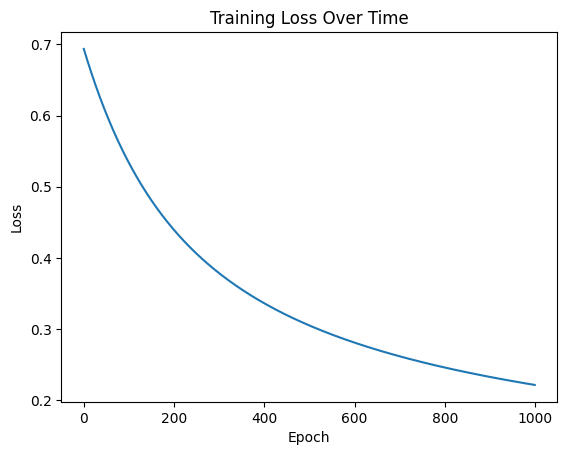

In [95]:
plt.plot(loss_list)
plt.title('Training Loss Over Time')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

In [ ]:
model.eval()

with torch.no_grad():
    outputs = model(X_eval)
    probabilities = torch.sigmoid(outputs)
    predictions = (probabilities > 0.5).float()
    accuracy = (predictions == y_eval).float().mean()

print(accuracy)
        

tensor(0.9590)


In [ ]:
from sklearn.linear_model import LogisticRegression
test_model = LogisticRegression()
test_model.fit(X_train.numpy(), y_train.ravel().numpy())

predicts = test_model.predict(X_eval.numpy())
score = accuracy_score(y_eval.ravel().numpy(), predicts)
print(score)

0.9692532942898975
